# Automatic Essay Scoring (AES)

**Autores:** Karolayne Teixeira da Silva e Tiago Barbosa de Lima

*Link para o respositório* [aqui](https://github.com/Tiagoblima/explanaible-essay-grading).

## Introdução
Nesta atividade, exploramos métodos de XAI aplicados para explicar a **incerteza** ou **erro** de modelos de machine learning no contexto de *Automatic Essay Scoring (AES)*. A incerteza pode surgir por variação nos dados ou limitação no conhecimento do modelo, e é essencial para entender as limitações de predição e melhorar a confiabilidade do sistema.

---

## Tema Escolhido
O tema abordado é: **"Métodos de XAI para explicação de incerteza ou erro de modelos"**. Adaptamos métodos de XAI para explicar a incerteza dos modelos construídos por meio de um modelo surrogate. 

Para isso, consideramos as incertezas:
- **Incerteza Aleatória (Aleatoric Uncertainty)**: média das incertezas de diferentes classificadores, representando variações intrínsecas dos dados.
- **Incerteza Epistêmica (Epistemic Uncertainty)**: variância das incertezas entre os modelos, refletindo a incerteza na própria modelagem.

---

## O Problema: Automatic Essay Scoring (AES)
*Automatic Essay Scoring (AES)* é uma tarefa de aprendizado de máquina que consiste em avaliar e pontuar automaticamente redações. Esse sistema pode ser usado para reduzir o tempo e custo de correções, como em avaliações de larga escala (por exemplo, o ENEM). Neste trabalho, simplificamos a tarefa para atribuir uma nota entre cinco categorias: 0, 50, 100, 150 e 200.

Para essa classificação, extraímos características como legibilidade, coesão e coerência para prever a pontuação final. Utilizamos múltiplos modelos para predizer a nota e, em seguida, calculamos a incerteza de cada modelo.

---

## O Conjunto de Dados
O conjunto de dados contém redações do UOL, totalizando 4570 amostras. As notas são atribuídas de acordo com aspectos gerais do texto, e os atributos incluem métricas relacionadas à estrutura textual e à argumentação.


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
TRAIN_PATH = "../data/features/essay_train_smote.csv"
TEST_PATH = "../data/features/essay_test_scaled.csv"

train_data = pd.read_csv(TRAIN_PATH)
test_data = pd.read_csv(TEST_PATH)

train_data.head()

,adapted_dalechall,adverbs_before_main_verb_ratio,brunet_indice,clauses_per_sentence,cncadc,cncadd,cncall,cncalter,cnccaus,cnccomp,...,wrdprp1p,wrdprp1s,wrdprp2,wrdprp2p,wrdprp2s,wrdprp3p,wrdprp3s,wrdverb,yule_k,target
0,0.246978,-0.201732,-1.110548,0.202734,-1.104210,-1.233077,-1.472221,0.397606,0.175013,0.197408,...,-0.181715,-0.084029,-0.128131,-0.034467,-0.124436,-0.456054,0.895740,-0.530422,-0.549369,3
1,0.018937,-1.038710,0.705326,-0.573028,0.484122,-0.533524,-0.660713,-0.951121,-0.049625,0.424183,...,-0.181715,-0.084029,-0.128131,-0.034467,-0.124436,-0.456054,-0.469185,0.249079,1.064041,3
2,0.108738,-0.206416,1.087333,0.703996,-0.310044,0.865582,1.368059,1.746333,-0.498902,-0.482918,...,-0.181715,-0.084029,-0.128131,-0.034467,-0.124436,-0.456054,-0.469185,0.249079,-0.106775,3
3,3.308101,4.269057,-0.160047,-0.107571,-0.310044,1.040470,1.570936,1.746333,-0.049625,0.197408,...,-0.181715,-0.084029,-0.128131,-0.034467,-0.124436,-0.456054,-0.469185,2.067915,-0.623890,2
4,-0.661692,-0.906873,1.141768,-0.029994,-1.104210,-1.407965,-1.472221,-0.951121,-0.723540,-0.482918,...,-0.181715,-0.084029,-0.128131,-0.034467,-0.124436,0.881789,-0.469185,-0.530422,1.871159,1


## Métodos

Para a análise de incerteza, implementamos e comparamos dois modelos: Random Forest e Regressão Logística.

- Pré-processamento dos Dados:
  - Separamos os atributos (X) e a variável alvo (Y).
  - Codificamos a incerteza de cada instância pela probabilidade máxima das previsões.

- Modelagem e Cálculo de Incerteza:
  - Incerteza Aleatória: média das incertezas entre os modelos.
  - Incerteza Epistêmica: variância das incertezas entre os modelos.

In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

feature_names = train_data.columns[:-1]
X_train = train_data.loc[:, feature_names].to_numpy()
Y_train = train_data.target.to_numpy()

X_test = test_data.loc[:, feature_names].to_numpy()
Y_test = test_data.target.to_numpy()

rf_clf = RandomForestClassifier(max_depth=12, random_state=0).fit(X_train, Y_train)
lr_clf = LogisticRegression(random_state=0).fit(X_train, Y_train)
clf_list = [rf_clf, lr_clf]

def calculate_uncertainty(clf, x_test):
    probs = clf.predict_proba(x_test)
    max_probs = probs.max(axis=1)
    uncertainty = 1 - max_probs
    return uncertainty


C:\Users\karo.txs\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Cálculo de Incertezas para Cada Modelo

In [17]:
uncertainties = {model.__class__.__name__: calculate_uncertainty(model, X_test) for model in clf_list}
uncertainty_df = pd.DataFrame(uncertainties).set_index(np.array([f"x{i}" for i in range(X_test.shape[0])]))

# Calculando Incerteza Aleatória (média) e Epistêmica (variância)
agg_uncertainty_df = uncertainty_df.agg(['mean', 'var'], axis=1).rename(columns={
    'mean': "Incerteza Aleatória",
    'var': "Incerteza Epistêmica"
})
agg_uncertainty_df.head()


,Incerteza Aleatória,Incerteza Epistêmica
x0,0.407627,0.008151
x1,0.485618,0.063453
x2,0.556082,0.018364
x3,0.595787,0.000482
x4,0.467710,0.057949


### Resultados

### Visualização da Incerteza

#### Relações entre varáveis e a incerteza aleatória
Analisamos as relações entre duas variáveis de interesse e a incerteza aleatória para entender melhor a incerteza nos dados de entrada.

In [14]:
test_data.head()

,adapted_dalechall,adverbs_before_main_verb_ratio,brunet_indice,clauses_per_sentence,cncadc,cncadd,cncall,cncalter,cnccaus,cnccomp,...,wrdprp1p,wrdprp1s,wrdprp2,wrdprp2p,wrdprp2s,wrdprp3p,wrdprp3s,wrdverb,yule_k,target
0,-1.347021,-0.472203,0.515769,-0.601238,0.484122,2.789352,2.585322,-0.951121,0.399652,-0.029367,...,-0.181715,-0.084029,-0.128131,-0.034467,-0.124436,-0.456054,-0.469185,0.682136,-0.097384,2
1,2.198038,-0.094002,-0.845537,2.297294,-1.104210,-0.358636,-0.660713,-0.951121,-0.723540,-1.163243,...,-0.181715,-0.084029,-0.128131,-0.034467,-0.124436,-0.456054,-0.469185,-1.136700,-0.453588,2
2,-0.748844,-0.158640,0.694646,-0.553634,0.484122,1.215358,1.165182,-0.276757,0.175013,0.650958,...,-0.181715,-0.084029,-0.128131,-0.034467,-0.124436,-0.456054,-0.469185,1.028580,0.090033,3
3,-0.273935,-0.708062,-0.519672,-0.262723,0.484122,-0.183748,-0.052081,-0.951121,-0.498902,-0.709693,...,-0.181715,-0.084029,-0.128131,-0.034467,-0.124436,-0.456054,-0.469185,-0.703644,-0.278633,3
4,0.741819,1.049592,-1.005242,-0.169632,-1.104210,-0.008859,-0.457836,0.397606,-0.948178,-0.936468,...,-0.181715,-0.084029,-0.128131,-0.034467,-0.124436,-0.456054,-0.469185,-0.876866,-0.294454,2


In [34]:
def plot_feature_uncertainty_scatter(selected_features, agg_uncertainty_df, test_data):
    agg_uncertainty_df = agg_uncertainty_df.reset_index(drop=True)
    test_data_selected = test_data[selected_features].reset_index(drop=True)

    # Concatenar as colunas de interesse do test_data ao DataFrame de incerteza
    agg_uncertainty_df = pd.concat([agg_uncertainty_df, test_data_selected], axis=1)
    agg_uncertainty_df = agg_uncertainty_df.loc[:, ~agg_uncertainty_df.columns.duplicated()]

    print("Plotando o gráfico de dispersão com as colunas selecionadas...")
    fig, ax = plt.subplots(figsize=(12, 8))
    _ = sns.scatterplot(data=agg_uncertainty_df.dropna(), x=selected_features[0], y=selected_features[1], 
                              hue="Incerteza Aleatória", palette="viridis", alpha=0.6, s=60, ax=ax)
    ax.set_title("Dispersão das Características com Incerteza Aleatória")
    ax.set_xlabel(selected_features[0])
    ax.set_ylabel(selected_features[1])
    
    norm = plt.Normalize(agg_uncertainty_df["Incerteza Aleatória"].min(), agg_uncertainty_df["Incerteza Aleatória"].max())
    sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
    sm.set_array([])
    fig.colorbar(sm, ax=ax, label="Incerteza Aleatória")
    
    plt.show()


Plotando o gráfico de dispersão com as colunas selecionadas...


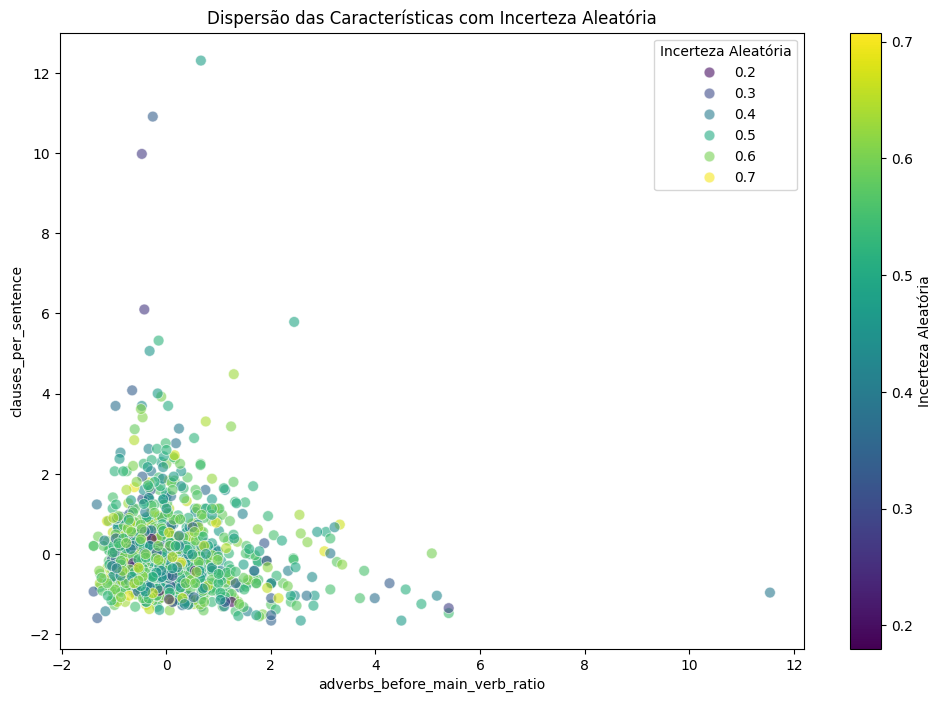

In [33]:
selected_features = ["adverbs_before_main_verb_ratio", "clauses_per_sentence"]
plot_feature_uncertainty_scatter(selected_features, agg_uncertainty_df, test_data)

#### Histograma da Incerteza Aleatória e Epistêmica
Visualizar a distribuição das incertezas aleatória e epistêmica no conjunto de dados de teste. Isso ajuda a entender a frequência e magnitude das incertezas geradas pelos modelos.

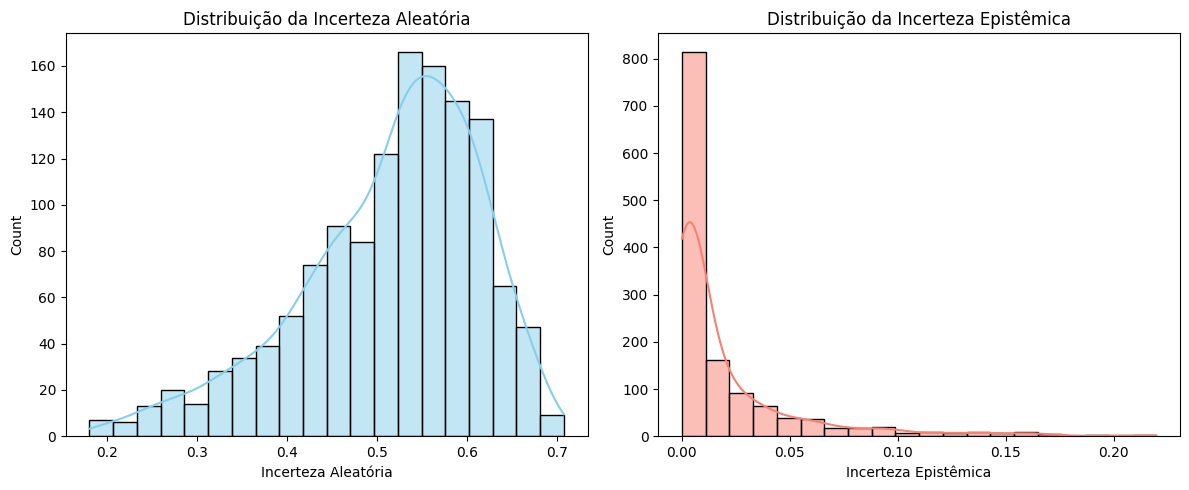

In [35]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(agg_uncertainty_df["Incerteza Aleatória"], bins=20, kde=True, color='skyblue')
plt.title("Distribuição da Incerteza Aleatória")
plt.xlabel("Incerteza Aleatória")

plt.subplot(1, 2, 2)
sns.histplot(agg_uncertainty_df["Incerteza Epistêmica"], bins=20, kde=True, color='salmon')
plt.title("Distribuição da Incerteza Epistêmica")
plt.xlabel("Incerteza Epistêmica")

plt.tight_layout()
plt.show()

#### Boxplot de Incertezas por Intervalos de Notas
Comparar as incertezas associadas a diferentes intervalos de notas (ou classes) e ver se há padrões específicos de incerteza para cada classe.

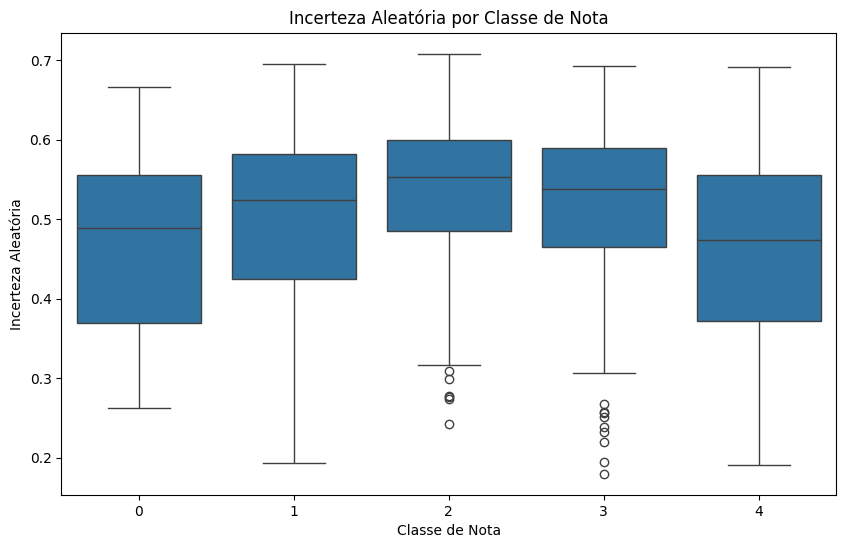

In [36]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=test_data, x="target", y=agg_uncertainty_df["Incerteza Aleatória"])
plt.title("Incerteza Aleatória por Classe de Nota")
plt.xlabel("Classe de Nota")
plt.ylabel("Incerteza Aleatória")
plt.show()


#### Matriz de Correlação entre Features e Incerteza
Analisar a relação entre cada feature e as incertezas aleatória e epistêmica. Isso pode ajudar a identificar quais características do texto estão mais associadas a alta incerteza.

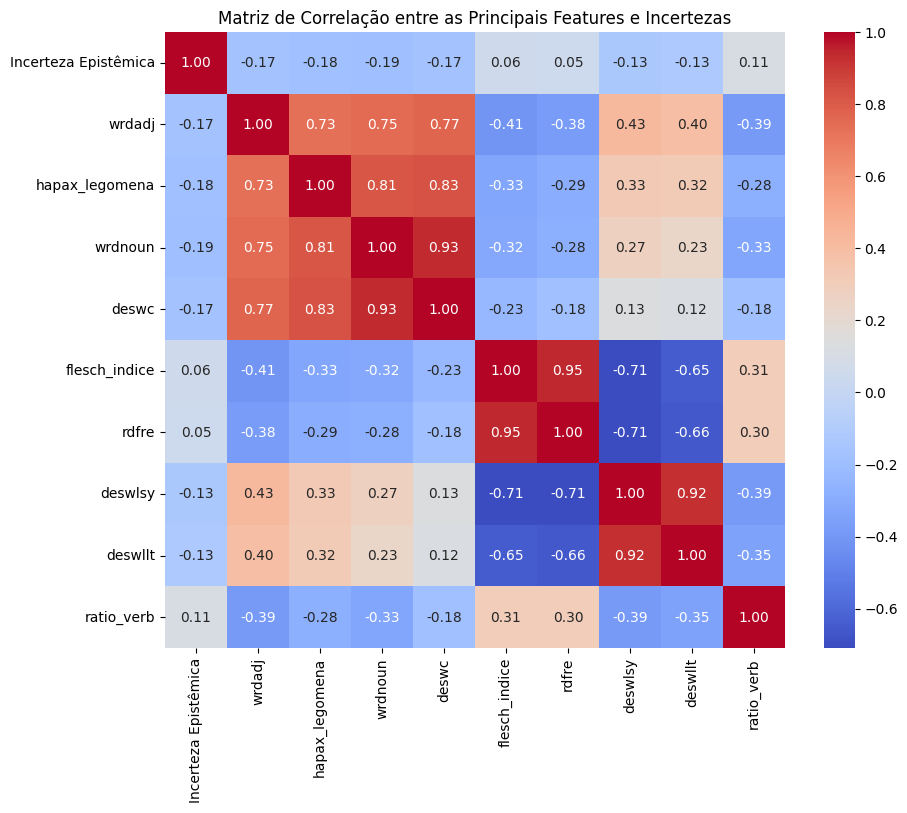

In [39]:
correlation_data = pd.concat([test_data[feature_names], agg_uncertainty_df[["Incerteza Aleatória", "Incerteza Epistêmica"]]], axis=1)
corr_matrix = correlation_data.corr()

top_k = 10 
correlations_with_uncertainty = corr_matrix["Incerteza Aleatória"].abs().sort_values(ascending=False)
top_features = correlations_with_uncertainty.index[1:top_k+1]  # Pula "Incerteza Aleatória" e seleciona as Top-K

# selected_features = ["feature1", "feature2", "feature3", ..., "Incerteza Aleatória", "Incerteza Epistêmica"]

selected_corr_matrix = corr_matrix.loc[top_features, top_features]

plt.figure(figsize=(10, 8))
sns.heatmap(selected_corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlação entre as Principais Features e Incertezas")
plt.show()


### Importância dos Atributos no Modelo Surrogate
Usamos um modelo surrogate para prever a incerteza e identificamos os atributos que mais influenciam o modelo de incerteza.

In [24]:
from sklearn.tree import DecisionTreeRegressor

#### Treinando um modelo surrogate com a incerteza aleatória como variável alvo

In [25]:
surrogate_model = DecisionTreeRegressor()
surrogate_model.fit(X_test, agg_uncertainty_df["Incerteza Aleatória"])

DecisionTreeRegressor()

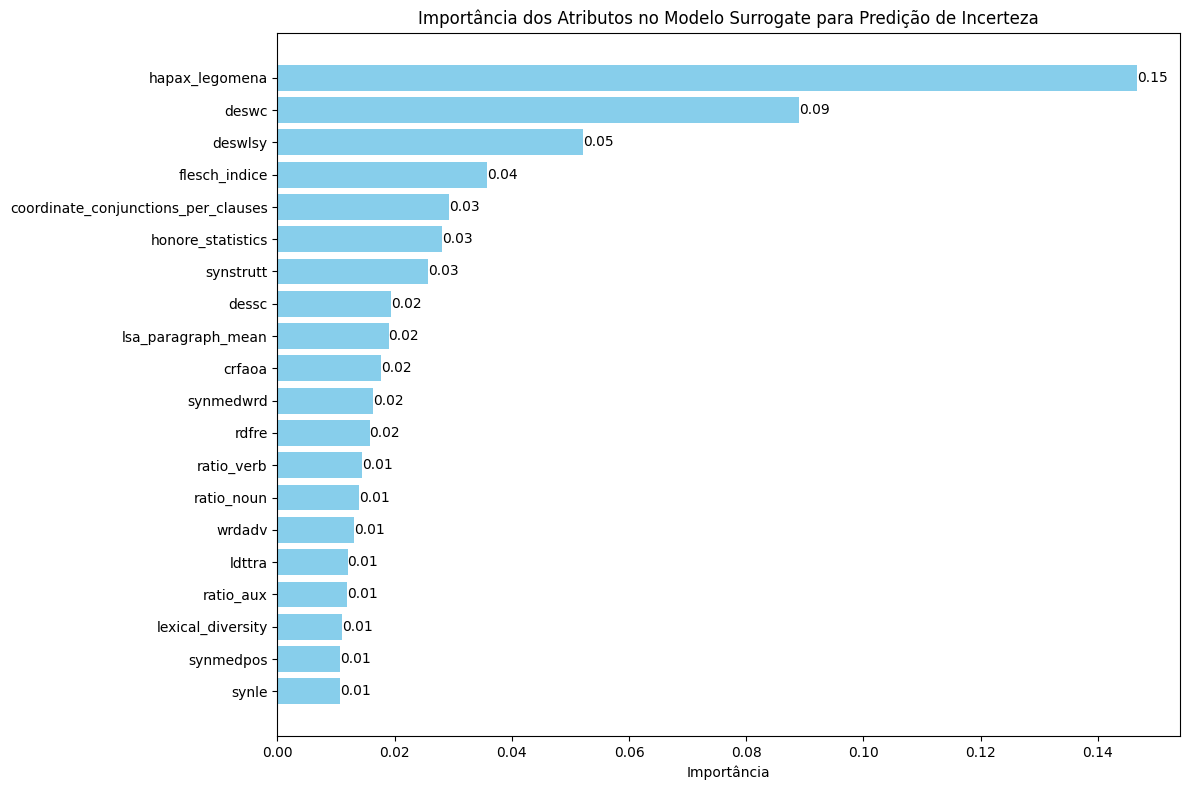

In [ ]:
limit = 20

importances = surrogate_model.feature_importances_
indices = np.argsort(importances)[::-1]  # Ordenar em ordem decrescente
sorted_features = [feature_names[i] for i in indices][:limit]
sorted_importances = importances[indices][:limit]

plt.figure(figsize=(12, 8))
plt.barh(sorted_features, sorted_importances, color="skyblue")
plt.xlabel("Importância")
plt.title("Importância dos Atributos no Modelo Surrogate para Predição de Incerteza")

for index, value in enumerate(sorted_importances):
    plt.text(value, index, f"{value:.2f}", va='center')

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


#### Mapeamento de Importância de Features e Incertezas em um Modelo Surrogate (com SHAP)

C:\Users\karo.txs\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


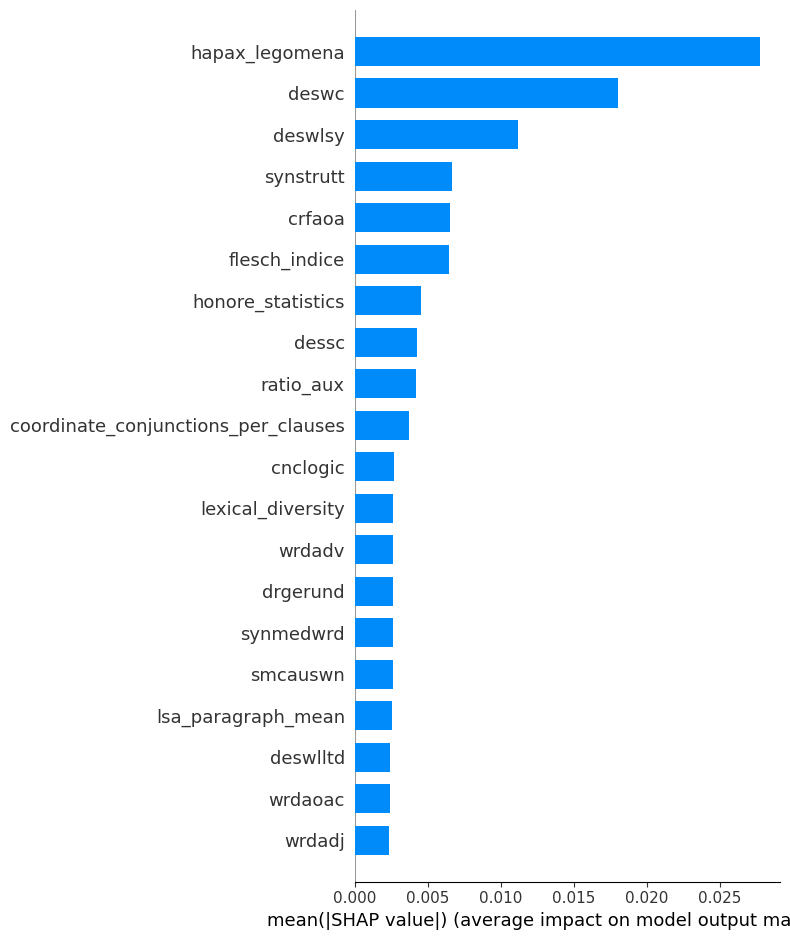

In [ ]:
import shap

surrogate_model = DecisionTreeRegressor()
surrogate_model.fit(X_test, agg_uncertainty_df["Incerteza Aleatória"])

# Explicações SHAP para o modelo surrogate
explainer = shap.TreeExplainer(surrogate_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, feature_names=feature_names, plot_type="bar", show=True)
